# Winam Gulf pipeline — outputs inventory

This notebook inventories every output produced by the three existing notebooks
by **scanning the actual files in Google Drive** (filenames on disk), then
reports counts, coverage time series and other progress statistics.

It is read-only: it never re-runs Earth Engine, classification or the panel
model. It only looks at what each notebook is *expected* to have written, based
on the output folders and filename conventions in their code.

| # | Source notebook | Drive output location | Main products |
|---|-----------------|-----------------------|---------------|
| 1 | `Batch_Export.ipynb` | `MyDrive/GEE_Exports_validated_snapshots/` | Per-date predictor GeoTIFFs (S2 16-band, S1/SCC 3-band) + manifest CSVs |
| 2 | `Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb` | `MyDrive/Winam_RF_Training_Data/` | Classified / probability / rule GeoTIFFs, area tables, time-series tables, figures, models |
| 3 | `winam_wh_spatial_panel_test_model.ipynb` | `MyDrive/WH_spatial_panel_test/` | Spatial-panel grid, panel CSV, predictions, monthly summary, coefficients |

**How to read the satellite labels:** `S2` = Sentinel-2 optical, `S1` =
Sentinel-1 SAR (the export prefix is `s1_scc` for the slope/angle-corrected
product). Every predictor GeoTIFF that reaches Drive already passed
`Batch_Export.ipynb`'s coverage gate, so each exported `.tif` is treated as one
**suitable** snapshot for that sensor and date.


## 1. Setup — mount Drive and imports

In [1]:
# Mount Google Drive (Colab). Outside Colab this is skipped and you can point
# DRIVE_MYDRIVE at any folder that mirrors your Drive layout.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception as exc:
    print('Google Drive not mounted automatically (not in Colab?):', exc)
    IN_COLAB = False


Mounted at /content/drive


In [2]:
import re
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)

try:
    from IPython.display import display
except Exception:  # plain Python fallback
    def display(x):
        print(x)


## 2. Configuration — expected output locations

These paths and filename conventions are taken directly from the three
notebooks. Edit `DRIVE_MYDRIVE` only if your Drive root differs.


In [3]:
# Root of your Google Drive. Matches the three notebooks' '/content/drive/MyDrive'.
DRIVE_MYDRIVE = Path('/content/drive/MyDrive')

# --- Notebook 1: Batch_Export.ipynb -------------------------------------------------
BATCH_EXPORT_DIR = DRIVE_MYDRIVE / 'GEE_Exports_validated_snapshots'

# --- Notebook 2: Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb ----------------
CLASSIFIER_ROOT = DRIVE_MYDRIVE / 'Winam_RF_Training_Data'
CLASSIFIER_MODEL_DIR = CLASSIFIER_ROOT / 'models'
CLASSIFIER_OUTPUT_DIR = CLASSIFIER_ROOT / 'outputs'
CLASSIFIER_BATCH_DIR = CLASSIFIER_OUTPUT_DIR / 'full_stack_batch'
CLASSIFIER_CLASSIFIED_DIR = CLASSIFIER_BATCH_DIR / 'classified_geotiffs'
CLASSIFIER_TABLE_DIR = CLASSIFIER_BATCH_DIR / 'tables'
CLASSIFIER_FIGURE_DIR = CLASSIFIER_BATCH_DIR / 'figures'
CLASSIFIER_QUICKLOOK_DIR = CLASSIFIER_BATCH_DIR / 'quicklooks'
# Training-point CSVs are inputs to that notebook, listed here for completeness.
CLASSIFIER_TRAINING_CSVS = [CLASSIFIER_ROOT / 'SV_S2_Training.csv',
                            CLASSIFIER_ROOT / 'SV_S1_Training.csv']

# --- Notebook 3: winam_wh_spatial_panel_test_model.ipynb -----------------------------
PANEL_OUTPUT_DIR = DRIVE_MYDRIVE / 'WH_spatial_panel_test'

# Where this inventory notebook writes its own consolidated CSVs.
INVENTORY_OUTPUT_DIR = DRIVE_MYDRIVE / 'Winam_pipeline_inventory'

ALL_SCAN_DIRS = {
    'Batch_Export exports': BATCH_EXPORT_DIR,
    'Classifier models': CLASSIFIER_MODEL_DIR,
    'Classifier outputs (root)': CLASSIFIER_OUTPUT_DIR,
    'Classifier classified GeoTIFFs': CLASSIFIER_CLASSIFIED_DIR,
    'Classifier tables': CLASSIFIER_TABLE_DIR,
    'Classifier figures': CLASSIFIER_FIGURE_DIR,
    'Classifier quicklooks': CLASSIFIER_QUICKLOOK_DIR,
    'Panel model outputs': PANEL_OUTPUT_DIR,
}

print('Expected output folders (existence shown):')
for label, path in ALL_SCAN_DIRS.items():
    flag = 'OK ' if path.exists() else 'MISSING'
    print(f'  [{flag}] {label}: {path}')


Expected output folders (existence shown):
  [OK ] Batch_Export exports: /content/drive/MyDrive/GEE_Exports_validated_snapshots
  [OK ] Classifier models: /content/drive/MyDrive/Winam_RF_Training_Data/models
  [OK ] Classifier outputs (root): /content/drive/MyDrive/Winam_RF_Training_Data/outputs
  [OK ] Classifier classified GeoTIFFs: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/classified_geotiffs
  [OK ] Classifier tables: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/tables
  [OK ] Classifier figures: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/figures
  [OK ] Classifier quicklooks: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/quicklooks
  [OK ] Panel model outputs: /content/drive/MyDrive/WH_spatial_panel_test


## 3. Helper functions (filename parsing + directory scanning)

In [4]:
# Predictor-export prefix used by Batch_Export.ipynb and reused by the classifier:
#   winam_s2_predictors_2019-04-03_to_2019-04-04
#   winam_s1_scc_predictors_2018-11-12_to_2018-11-13
# Earth Engine may append tile shards (-0000000000-0000008192) or .tif.
PREDICTOR_PREFIX_RE = re.compile(
    r'^(?P<prefix>winam_(?P<token>s2|s1_scc|s1)_predictors_'
    r'(?P<start>\d{4}-\d{2}-\d{2})_to_(?P<end>\d{4}-\d{2}-\d{2}))'
)

# Classifier output filenames build on that prefix:
#   {prefix}_local_{model_slug}.tif         -> model classification
#   {prefix}_local_{model_slug}_proba.tif   -> max-probability raster
#   {prefix}_local_rules.tif                -> paper-rule classification
#   {prefix}_local_{model_slug}_patch_cleaned.tif -> patch-cleaned (usually S1)
RASTER_SUFFIXES = {'.tif', '.tiff', ''}


def sensor_from_token(token):
    """Map an export filename token to a satellite label."""
    token = (token or '').lower()
    if token == 's2':
        return 'S2'
    if token in ('s1', 's1_scc'):
        return 'S1'
    return 'unknown'


def parse_predictor_name(name):
    """Return dict(prefix, sensor, start_date, end_date) or None."""
    m = PREDICTOR_PREFIX_RE.match(Path(name).stem if Path(name).suffix else name)
    # Stem strips one suffix; EE files may have no suffix, so match on name too.
    if m is None:
        m = PREDICTOR_PREFIX_RE.match(str(name))
    if m is None:
        return None
    return {
        'prefix': m.group('prefix'),
        'sensor': sensor_from_token(m.group('token')),
        'start_date': pd.Timestamp(m.group('start')),
        'end_date': pd.Timestamp(m.group('end')),
    }


def classifier_product(name):
    """Classify a classifier-output raster filename into a product type."""
    stem = Path(name).stem.lower()
    if not stem.startswith('winam_'):
        return None
    if '_proba' in stem:
        return 'probability'
    if stem.endswith('_local_rules'):
        return 'rules'
    if '_patch_cleaned' in stem and '_local_' in stem:
        return 'model_patch_cleaned'
    if '_local_' in stem:
        return 'model'
    return None


def scan_dir(path, recursive=True):
    """Return a DataFrame of every file under ``path`` (one row per file)."""
    path = Path(path)
    cols = ['name', 'suffix', 'parent', 'rel_path', 'full_path', 'size_bytes', 'size_mb', 'modified']
    if not path.exists():
        return pd.DataFrame(columns=cols)
    it = path.rglob('*') if recursive else path.glob('*')
    rows = []
    for fp in it:
        if not fp.is_file():
            continue
        try:
            st = fp.stat()
            size, mtime = st.st_size, datetime.fromtimestamp(st.st_mtime)
        except OSError:
            size, mtime = np.nan, pd.NaT
        rows.append({
            'name': fp.name,
            'suffix': fp.suffix.lower(),
            'parent': fp.parent.name,
            'rel_path': str(fp.relative_to(path)),
            'full_path': str(fp),
            'size_bytes': size,
            'size_mb': round(size / 1e6, 3) if size == size else np.nan,
            'modified': mtime,
        })
    return pd.DataFrame(rows, columns=cols)


def human_mb(byte_series):
    total = float(np.nansum(byte_series))
    return f'{total / 1e6:,.1f} MB ({total / 1e9:,.2f} GB)'


def monthly_counts(df, date_col, group_col, count_col=None):
    """Counts per group per calendar month, reindexed over the full month range
    so empty months show as zero."""
    if df.empty:
        return pd.DataFrame()
    d = df.dropna(subset=[date_col]).copy()
    if d.empty:
        return pd.DataFrame()
    d['month'] = d[date_col].dt.to_period('M').dt.to_timestamp()
    if count_col is None:
        wide = (d.groupby([group_col, 'month']).size()
                  .rename('count').reset_index())
    else:
        wide = (d.groupby([group_col, 'month'])[count_col].nunique()
                  .rename('count').reset_index())
    full_months = pd.date_range(d['month'].min(), d['month'].max(), freq='MS')
    groups = sorted(wide[group_col].unique())
    idx = pd.MultiIndex.from_product([groups, full_months], names=[group_col, 'month'])
    wide = (wide.set_index([group_col, 'month'])
                 .reindex(idx, fill_value=0)
                 .reset_index())
    return wide


print('Helpers ready.')


Helpers ready.


## 4. Notebook 1 — `Batch_Export.ipynb` predictor exports

Every `.tif` here is a per-acquisition-date predictor snapshot that already
passed the coverage QA gate, so each one is a **suitable** export. Earth Engine
sometimes writes a single file per date and sometimes several tile shards, so we
group shards back to one *dataset* per `prefix` before counting.


In [5]:
batch_files = scan_dir(BATCH_EXPORT_DIR)
print(f'Files found in {BATCH_EXPORT_DIR}:', len(batch_files))

# Split into predictor GeoTIFFs vs. the manifest/bookkeeping CSVs.
predictor_rows = []
for _, r in batch_files.iterrows():
    if r['suffix'] not in RASTER_SUFFIXES:
        continue
    parsed = parse_predictor_name(r['name'])
    if parsed is None:
        continue
    predictor_rows.append({**parsed,
                           'name': r['name'],
                           'size_bytes': r['size_bytes'],
                           'modified': r['modified']})

predictor_files = pd.DataFrame(predictor_rows)
batch_csvs = batch_files[batch_files['suffix'] == '.csv']

if predictor_files.empty:
    print('No predictor GeoTIFFs found yet. Run Batch_Export.ipynb first.')
else:
    print(f'Predictor GeoTIFF files (incl. tile shards): {len(predictor_files)}')
    print('Manifest / bookkeeping CSVs present:', list(batch_csvs['name']))


Files found in /content/drive/MyDrive/GEE_Exports_validated_snapshots: 1631
Predictor GeoTIFF files (incl. tile shards): 1628
Manifest / bookkeeping CSVs present: ['winam_snapshot_validated_predictor_planned_rows.csv', 'winam_snapshot_validated_predictor_pending_rows.csv', 'winam_snapshot_validated_predictor_manifest.csv']


In [6]:
# Collapse tile shards to one dataset per prefix.
if predictor_files.empty:
    predictor_datasets = pd.DataFrame(
        columns=['prefix', 'sensor', 'start_date', 'end_date', 'n_files', 'size_bytes', 'modified'])
else:
    predictor_datasets = (
        predictor_files.groupby(['prefix', 'sensor', 'start_date', 'end_date'], as_index=False)
        .agg(n_files=('name', 'size'),
             size_bytes=('size_bytes', 'sum'),
             modified=('modified', 'max'))
        .sort_values('start_date')
        .reset_index(drop=True)
    )

print(f'Distinct exported predictor datasets (snapshots): {len(predictor_datasets)}')
display(predictor_datasets.head(10))


Distinct exported predictor datasets (snapshots): 814


,prefix,sensor,start_date,end_date,n_files,size_bytes,modified
0,winam_s1_scc_predictors_2014-12-30_to_2014-12-31,S1,2014-12-30,2014-12-31,2,349095311,2026-05-28 23:23:34
1,winam_s1_scc_predictors_2015-01-13_to_2015-01-14,S1,2015-01-13,2015-01-14,2,367249398,2026-05-29 00:08:40
2,winam_s1_scc_predictors_2015-04-07_to_2015-04-08,S1,2015-04-07,2015-04-08,2,367339112,2026-05-28 23:36:36
3,winam_s1_scc_predictors_2015-04-17_to_2015-04-18,S1,2015-04-17,2015-04-18,2,353107481,2026-05-28 23:34:02
4,winam_s1_scc_predictors_2015-09-08_to_2015-09-09,S1,2015-09-08,2015-09-09,2,350626301,2026-05-28 23:59:56
5,winam_s1_scc_predictors_2015-12-13_to_2015-12-14,S1,2015-12-13,2015-12-14,2,350400988,2026-05-29 00:04:39
6,winam_s1_scc_predictors_2016-07-04_to_2016-07-05,S1,2016-07-04,2016-07-05,2,351410683,2026-05-29 00:23:33
7,winam_s1_scc_predictors_2016-09-26_to_2016-09-27,S1,2016-09-26,2016-09-27,2,351438012,2026-05-29 00:28:34
8,winam_s1_scc_predictors_2016-10-20_to_2016-10-21,S1,2016-10-20,2016-10-21,2,351548522,2026-05-29 00:17:57
9,winam_s1_scc_predictors_2016-11-13_to_2016-11-14,S1,2016-11-13,2016-11-14,2,351218340,2026-05-29 00:34:27


Exported predictor snapshots per satellite:


,sensor,n_snapshots,n_files,first_date,last_date,total_size
0,S1,456,912,2014-12-30,2026-06-06,"161,728.8 MB"
1,S2,358,716,2017-04-02,2026-06-14,"448,205.7 MB"


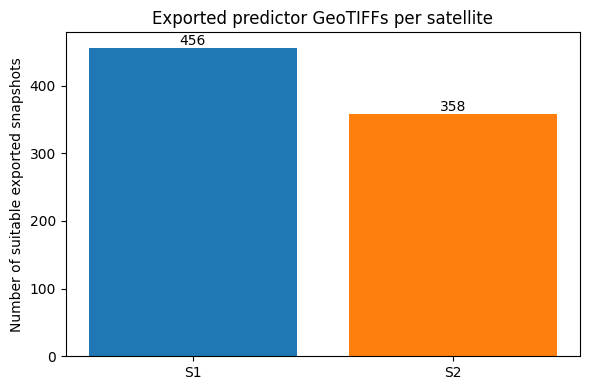

In [7]:
# --- Number of exports per satellite ---
if predictor_datasets.empty:
    print('No exported datasets to summarise.')
else:
    per_sat = (predictor_datasets.groupby('sensor')
               .agg(n_snapshots=('prefix', 'nunique'),
                    n_files=('n_files', 'sum'),
                    first_date=('start_date', 'min'),
                    last_date=('start_date', 'max'),
                    total_size_bytes=('size_bytes', 'sum'))
               .reset_index())
    per_sat['total_size'] = per_sat['total_size_bytes'].apply(lambda b: f'{b/1e6:,.1f} MB')
    print('Exported predictor snapshots per satellite:')
    display(per_sat.drop(columns='total_size_bytes'))

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(per_sat['sensor'], per_sat['n_snapshots'],
           color=['#1f77b4', '#ff7f0e'][:len(per_sat)])
    for i, v in enumerate(per_sat['n_snapshots']):
        ax.text(i, v, str(int(v)), ha='center', va='bottom')
    ax.set_ylabel('Number of suitable exported snapshots')
    ax.set_title('Exported predictor GeoTIFFs per satellite')
    plt.tight_layout()
    plt.show()


sensor,S1,S2
month,,
2025-01-01,3,2
2025-02-01,2,5
2025-03-01,3,3
2025-04-01,2,4
2025-05-01,5,4
2025-06-01,4,6
2025-07-01,5,6
2025-08-01,4,4
2025-09-01,5,7


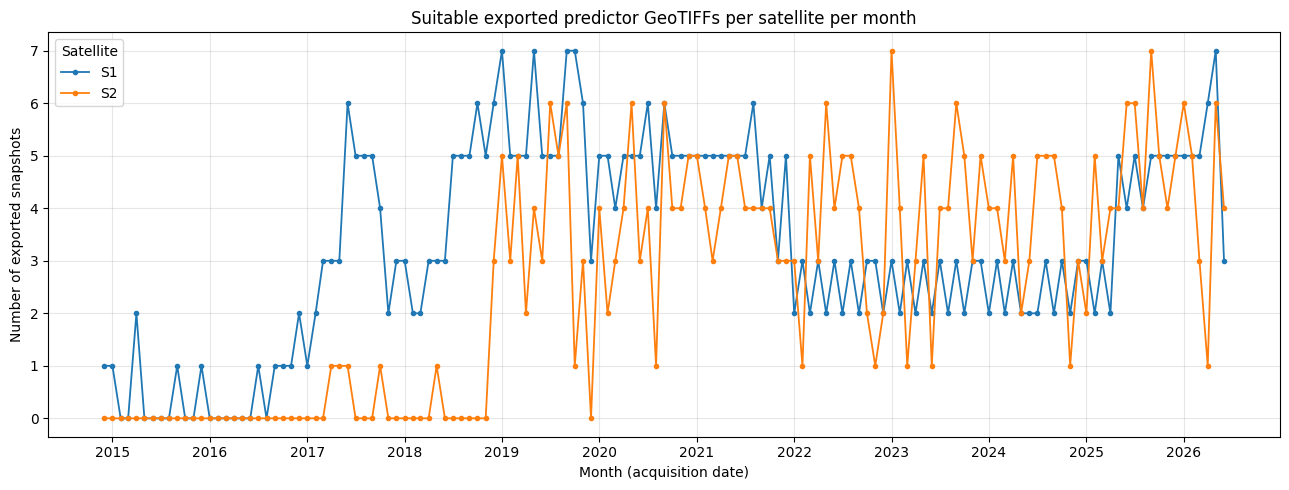

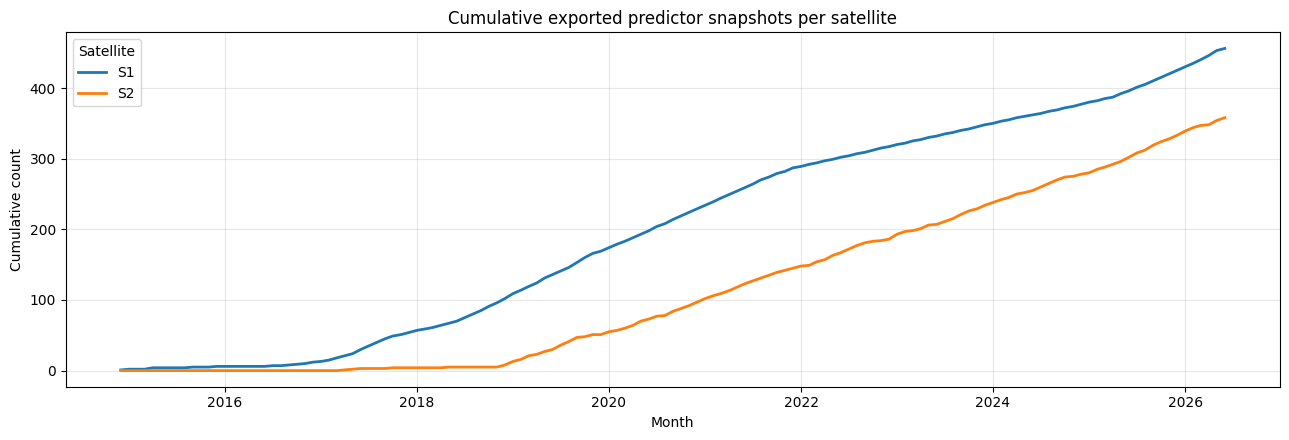

In [8]:
# --- Time series: suitable exported geotiffs per satellite per month ---
export_ts = monthly_counts(predictor_datasets, 'start_date', 'sensor')
if export_ts.empty:
    print('No dated exports to plot.')
else:
    pivot = export_ts.pivot(index='month', columns='sensor', values='count').fillna(0)
    display(pivot.tail(18))

    fig, ax = plt.subplots(figsize=(13, 5))
    for sensor in pivot.columns:
        ax.plot(pivot.index, pivot[sensor], marker='o', ms=3, linewidth=1.3, label=sensor)
    ax.set_title('Suitable exported predictor GeoTIFFs per satellite per month')
    ax.set_xlabel('Month (acquisition date)')
    ax.set_ylabel('Number of exported snapshots')
    ax.legend(title='Satellite')
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.tight_layout()
    plt.show()

    # Cumulative progress view.
    fig, ax = plt.subplots(figsize=(13, 4.5))
    for sensor in pivot.columns:
        ax.plot(pivot.index, pivot[sensor].cumsum(), linewidth=2, label=sensor)
    ax.set_title('Cumulative exported predictor snapshots per satellite')
    ax.set_xlabel('Month')
    ax.set_ylabel('Cumulative count')
    ax.legend(title='Satellite')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [9]:
# --- Per-year breakdown and coverage span ---
if not predictor_datasets.empty:
    by_year = (predictor_datasets.assign(year=predictor_datasets['start_date'].dt.year)
               .groupby(['sensor', 'year']).size()
               .unstack('sensor', fill_value=0))
    print('Exported snapshots per year:')
    display(by_year)

    span = (predictor_datasets.groupby('sensor')
            .agg(first=('start_date', 'min'), last=('start_date', 'max'),
                 distinct_months=('start_date', lambda s: s.dt.to_period('M').nunique()))
            .reset_index())
    print('Temporal coverage span per satellite:')
    display(span)


Exported snapshots per year:


sensor,S1,S2
year,,
2014,1,0
2015,5,0
2016,6,0
2017,42,4
2018,48,4
2019,67,43
2020,60,46
2021,58,48
2022,30,41


Temporal coverage span per satellite:


,sensor,first,last,distinct_months
0,S1,2014-12-30,2026-06-06,124
1,S2,2017-04-02,2026-06-14,95


## 5. Notebook 2 — Classifier full-stack outputs

The classifier turns each exported predictor snapshot into classified rasters
(`model`, `probability`, `rules`, and patch-cleaned variants), per-date area
tables, aggregate time-series tables, figures, quicklooks and saved models.


In [10]:
classified_files = scan_dir(CLASSIFIER_CLASSIFIED_DIR)
class_raster_rows = []
for _, r in classified_files.iterrows():
    if r['suffix'] not in RASTER_SUFFIXES:
        continue
    product = classifier_product(r['name'])
    parsed = parse_predictor_name(r['name'])
    if product is None or parsed is None:
        continue
    class_raster_rows.append({'sensor': parsed['sensor'],
                              'start_date': parsed['start_date'],
                              'prefix': parsed['prefix'],
                              'product': product,
                              'name': r['name'],
                              'size_bytes': r['size_bytes'],
                              'modified': r['modified']})

classified = pd.DataFrame(class_raster_rows)
if classified.empty:
    print('No classified GeoTIFFs found yet in', CLASSIFIER_CLASSIFIED_DIR)
else:
    print(f'Classified raster files: {len(classified)}')
    print('Counts by satellite x product:')
    display(pd.crosstab(classified['sensor'], classified['product'], margins=True))


Classified raster files: 8118
Counts by satellite x product:


product,model,probability,rules,All
sensor,,,,
S1,2700,1620,540,4860
S2,1806,1086,366,3258
All,4506,2706,906,8118


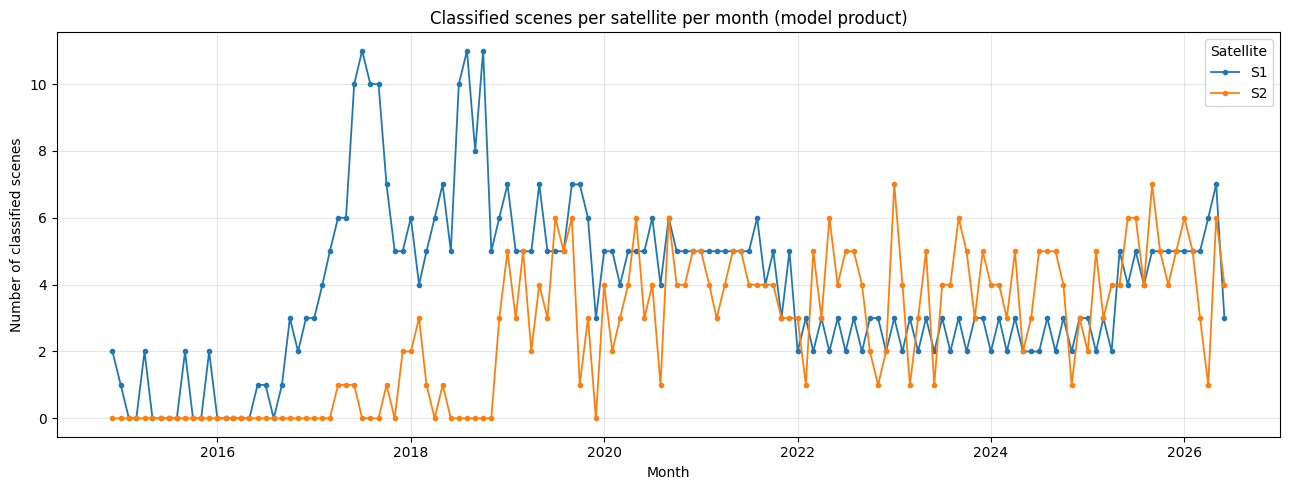

sensor,S1,S2
month,,
2025-01-01,3,2
2025-02-01,2,5
2025-03-01,3,3
2025-04-01,2,4
2025-05-01,5,4
2025-06-01,4,6
2025-07-01,5,6
2025-08-01,4,4
2025-09-01,5,7


In [11]:
# --- Classified-output time series per satellite per month (model product) ---
if not classified.empty:
    model_rasters = classified[classified['product'].isin(['model', 'model_patch_cleaned'])]
    # one classified scene per (sensor, prefix)
    model_scenes = model_rasters.drop_duplicates(['sensor', 'prefix'])
    class_ts = monthly_counts(model_scenes, 'start_date', 'sensor')
    if not class_ts.empty:
        pivot_c = class_ts.pivot(index='month', columns='sensor', values='count').fillna(0)
        fig, ax = plt.subplots(figsize=(13, 5))
        for sensor in pivot_c.columns:
            ax.plot(pivot_c.index, pivot_c[sensor], marker='o', ms=3, linewidth=1.3, label=sensor)
        ax.set_title('Classified scenes per satellite per month (model product)')
        ax.set_xlabel('Month')
        ax.set_ylabel('Number of classified scenes')
        ax.legend(title='Satellite')
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        display(pivot_c.tail(18))


In [12]:
# --- Inventory of the classifier's tables, figures, quicklooks, models ---
def summarise_folder(path, label):
    files = scan_dir(path)
    if files.empty:
        print(f'{label}: empty or missing ({path})')
        return files
    by_suffix = (files.groupby('suffix')
                 .agg(n=('name', 'size'), size_mb=('size_bytes', lambda b: round(np.nansum(b)/1e6, 2)))
                 .reset_index())
    print(f'{label}: {len(files)} files, {human_mb(files["size_bytes"])}')
    display(by_suffix)
    return files

table_files = summarise_folder(CLASSIFIER_TABLE_DIR, 'Classifier tables')
figure_files = summarise_folder(CLASSIFIER_FIGURE_DIR, 'Classifier figures')
quicklook_files = summarise_folder(CLASSIFIER_QUICKLOOK_DIR, 'Classifier quicklooks')
model_files = summarise_folder(CLASSIFIER_MODEL_DIR, 'Saved models')
output_root_files = summarise_folder(CLASSIFIER_OUTPUT_DIR, 'Classifier outputs (root, non-recursive)')


Classifier tables: 1637 files, 21.7 MB (0.02 GB)


,suffix,n,size_mb
0,.csv,1637,21.71


Classifier figures: 755 files, 5.4 MB (0.01 GB)


,suffix,n,size_mb
0,.csv,752,4.94
1,.gsheet,1,0.00
2,.png,2,0.46


Classifier quicklooks: 1812 files, 432.6 MB (0.43 GB)


,suffix,n,size_mb
0,.png,1812,432.61


Saved models: 6 files, 7.2 MB (0.01 GB)


,suffix,n,size_mb
0,.joblib,6,7.2


Classifier outputs (root, non-recursive): 12370 files, 14,008.3 MB (14.01 GB)


,suffix,n,size_mb
0,.csv,2402,26.67
1,.gsheet,1,0.00
2,.json,3,0.00
3,.png,1822,434.72
4,.tif,8142,13546.89


In [13]:
# Highlight the key aggregate deliverables the classifier is expected to write,
# and flag which exist. These are identified purely by filename.
EXPECTED_CLASSIFIER_KEY_FILES = {
    'export inventory table': 'winam_full_stack_export_inventory',
    'ready manifest': 'winam_full_stack_ready_manifest',
    'run log': 'winam_full_stack_run_log',
    'area-by-class (all dates)': 'winam_full_stack_area_by_class_all_dates',
    'floating-area time series': 'winam_full_stack_floating_area_timeseries',
    'floating-area time series (wide)': 'winam_full_stack_floating_area_timeseries_wide',
    'floating-area summary': 'winam_full_stack_floating_area_summary',
    'confidence-masked area (all dates)': 'winam_full_stack_confidence_area_all_dates',
    'time-series figure': 'winam_full_stack_floating_area_timeseries',
    'export-availability figure': 'winam_full_stack_export_availability',
}
search_pool = pd.concat([table_files, figure_files], ignore_index=True)     if not table_files.empty or not figure_files.empty else pd.DataFrame(columns=['name'])
rows = []
for label, stub in EXPECTED_CLASSIFIER_KEY_FILES.items():
    matches = search_pool[search_pool['name'].str.contains(stub, regex=False, na=False)]         if not search_pool.empty else search_pool
    rows.append({'deliverable': label, 'present': not matches.empty,
                 'n_matching_files': len(matches),
                 'example': matches['name'].iloc[0] if not matches.empty else ''})
print('Classifier key aggregate deliverables (by filename):')
display(pd.DataFrame(rows))

# Per-date area tables (one per classified dataset).
if not table_files.empty:
    per_date_area = table_files[table_files['name'].str.contains('_area_by_class_', na=False)]
    per_date_conf = table_files[table_files['name'].str.contains('_confidence_area_', na=False)]
    print(f'Per-date area-by-class tables: {len(per_date_area)}')
    print(f'Per-date confidence-area tables: {len(per_date_conf)}')


Classifier key aggregate deliverables (by filename):


,deliverable,present,n_matching_files,example
0,export inventory table,True,3,winam_full_stack_export_inventory_route_b_s1_s...
1,ready manifest,True,2,winam_full_stack_ready_manifest_route_b_s1_scc...
2,run log,True,1,winam_full_stack_run_log_route_b_s1_scc_spatia...
3,area-by-class (all dates),True,1,winam_full_stack_area_by_class_all_dates_route...
4,floating-area time series,True,3,winam_full_stack_floating_area_timeseries_rout...
5,floating-area time series (wide),True,1,winam_full_stack_floating_area_timeseries_wide...
6,floating-area summary,True,1,winam_full_stack_floating_area_summary_route_b...
7,confidence-masked area (all dates),True,1,winam_full_stack_confidence_area_all_dates_rou...
8,time-series figure,True,3,winam_full_stack_floating_area_timeseries_rout...
9,export-availability figure,True,1,winam_full_stack_export_availability_route_b_s...


Per-date area-by-class tables: 815
Per-date confidence-area tables: 815


## 6. Notebook 3 — `winam_wh_spatial_panel_test_model.ipynb` outputs

The panel model consumes the classified rasters and writes a spatial-panel grid,
the panel CSV, monthly summaries, predictions, model coefficients and a grid
summary layer.


In [14]:
panel_files = scan_dir(PANEL_OUTPUT_DIR)
if panel_files.empty:
    print('No panel-model outputs found yet in', PANEL_OUTPUT_DIR)
else:
    print(f'Panel-model output files: {len(panel_files)}, {human_mb(panel_files["size_bytes"])}')
    display(panel_files[['name', 'suffix', 'size_mb', 'modified']].sort_values('name'))

EXPECTED_PANEL_FILES = {
    'spatial grid (GPKG)': ('winam_grid', '.gpkg'),
    'spatial grid (GeoJSON)': ('winam_grid', '.geojson'),
    'panel table': ('wh_spatial_panel_', '.csv'),
    'panel predictions': ('wh_spatial_panel_predictions_', '.csv'),
    'monthly summary': ('wh_monthly_summary_', '.csv'),
    'model coefficients': ('wh_model_coefficients_', '.csv'),
    'grid summary layer': ('wh_grid_summary_', '.gpkg'),
}
rows = []
for label, (stub, suffix) in EXPECTED_PANEL_FILES.items():
    if panel_files.empty:
        present, example = False, ''
    else:
        m = panel_files[panel_files['name'].str.contains(stub, regex=False, na=False)
                        & panel_files['name'].str.endswith(suffix)]
        present, example = (not m.empty), (m['name'].iloc[0] if not m.empty else '')
    rows.append({'deliverable': label, 'present': present, 'example': example})
print('Panel-model expected deliverables (by filename):')
display(pd.DataFrame(rows))


Panel-model output files: 36, 405.6 MB (0.41 GB)


,name,suffix,size_mb,modified
11,driver_cover_gam_effects_20260620_135807.csv,.csv,0.003,2026-06-20 13:58:07
18,driver_cover_gam_effects_20260620_193249.csv,.csv,0.004,2026-06-20 19:32:49
25,driver_cover_gam_effects_20260621_102954.csv,.csv,0.001,2026-06-21 10:29:54
12,driver_cover_gam_pdep_20260620_135807.csv,.csv,0.169,2026-06-20 13:58:07
19,driver_cover_gam_pdep_20260620_193249.csv,.csv,0.202,2026-06-20 19:32:49
26,driver_cover_gam_pdep_20260621_102954.csv,.csv,0.042,2026-06-21 10:29:54
27,driver_gam_cover_pdep.png,.png,0.208,2026-06-21 10:30:00
28,driver_gam_presence_pdep.png,.png,0.231,2026-06-21 10:30:03
9,driver_presence_gam_effects_20260620_135807.csv,.csv,0.003,2026-06-20 13:58:07
16,driver_presence_gam_effects_20260620_193249.csv,.csv,0.003,2026-06-20 19:32:49


Panel-model expected deliverables (by filename):


,deliverable,present,example
0,spatial grid (GPKG),True,winam_grid_500m.gpkg
1,spatial grid (GeoJSON),True,winam_grid_500m.geojson
2,panel table,True,wh_spatial_panel_500m_2021-01-01_to_2021-12-31...
3,panel predictions,True,wh_spatial_panel_predictions_500m_2021-01-01_t...
4,monthly summary,True,wh_monthly_summary_500m_2021-01-01_to_2021-12-...
5,model coefficients,True,wh_model_coefficients_500m_2021-01-01_to_2021-...
6,grid summary layer,True,wh_grid_summary_500m_2021-01-01_to_2021-12-31....


## 7. End-to-end progress dashboard

A funnel showing how many dated scenes have made it through each pipeline stage,
per satellite, plus an overall file/size summary across all three notebooks.


Pipeline funnel (dated scenes per stage):


,sensor,exported_predictor_snapshots,classified_scenes,classified_pct_of_exported
0,S2,358,366,102.2
1,S1,456,540,118.4


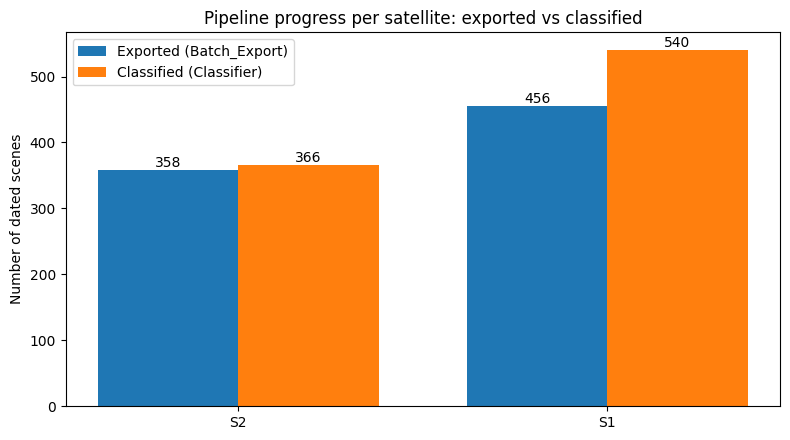

In [15]:
# --- Pipeline funnel: exported -> classified per satellite ---
funnel_rows = []
for sensor in ['S2', 'S1']:
    n_exported = 0 if predictor_datasets.empty else         predictor_datasets.loc[predictor_datasets['sensor'] == sensor, 'prefix'].nunique()
    if classified.empty:
        n_classified = 0
    else:
        n_classified = classified.loc[
            (classified['sensor'] == sensor)
            & classified['product'].isin(['model', 'model_patch_cleaned']),
            'prefix'].nunique()
    funnel_rows.append({'sensor': sensor,
                        'exported_predictor_snapshots': n_exported,
                        'classified_scenes': n_classified,
                        'classified_pct_of_exported':
                            round(100 * n_classified / n_exported, 1) if n_exported else np.nan})
funnel = pd.DataFrame(funnel_rows)
print('Pipeline funnel (dated scenes per stage):')
display(funnel)

if funnel[['exported_predictor_snapshots', 'classified_scenes']].to_numpy().sum() > 0:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    x = np.arange(len(funnel)); w = 0.38
    ax.bar(x - w/2, funnel['exported_predictor_snapshots'], w, label='Exported (Batch_Export)')
    ax.bar(x + w/2, funnel['classified_scenes'], w, label='Classified (Classifier)')
    ax.set_xticks(x); ax.set_xticklabels(funnel['sensor'])
    ax.set_ylabel('Number of dated scenes')
    ax.set_title('Pipeline progress per satellite: exported vs classified')
    ax.legend()
    for i, row in funnel.iterrows():
        ax.text(i - w/2, row['exported_predictor_snapshots'],
                int(row['exported_predictor_snapshots']), ha='center', va='bottom')
        ax.text(i + w/2, row['classified_scenes'],
                int(row['classified_scenes']), ha='center', va='bottom')
    plt.tight_layout()
    plt.show()


In [16]:
# --- Master file inventory across all three notebooks ---
inventory_parts = []
stage_dirs = {
    '1_Batch_Export': BATCH_EXPORT_DIR,
    '2_Classifier': CLASSIFIER_ROOT,
    '3_Panel_model': PANEL_OUTPUT_DIR,
}
for stage, root in stage_dirs.items():
    f = scan_dir(root)
    if f.empty:
        continue
    f = f.copy()
    f['stage'] = stage
    inventory_parts.append(f)

if inventory_parts:
    master = pd.concat(inventory_parts, ignore_index=True)
    overview = (master.groupby('stage')
                .agg(n_files=('name', 'size'),
                     total_mb=('size_bytes', lambda b: round(np.nansum(b)/1e6, 1)),
                     last_modified=('modified', 'max'))
                .reset_index())
    print('Overall inventory by pipeline stage:')
    display(overview)
    print('Grand total:', len(master), 'files,', human_mb(master['size_bytes']))

    by_suffix = (master.groupby(['stage', 'suffix'])
                 .agg(n=('name', 'size'),
                      size_mb=('size_bytes', lambda b: round(np.nansum(b)/1e6, 1)))
                 .reset_index()
                 .sort_values(['stage', 'n'], ascending=[True, False]))
    print('File types per stage:')
    display(by_suffix)
else:
    master = pd.DataFrame()
    print('No files found in any stage. Have the notebooks been run yet?')


Overall inventory by pipeline stage:


,stage,n_files,total_mb,last_modified
0,1_Batch_Export,1631,609935.1,2026-06-16 05:40:41
1,2_Classifier,12378,14016.2,2026-06-20 23:44:51
2,3_Panel_model,36,405.6,2026-06-21 11:48:39


Grand total: 14045 files, 624,356.9 MB (624.36 GB)
File types per stage:


,stage,suffix,n,size_mb
1,1_Batch_Export,.tif,1628,609934.5
0,1_Batch_Export,.csv,3,0.5
7,2_Classifier,.tif,8142,13546.9
2,2_Classifier,.csv,2404,27.4
6,2_Classifier,.png,1822,434.7
4,2_Classifier,.joblib,6,7.2
5,2_Classifier,.json,3,0.0
3,2_Classifier,.gsheet,1,0.0
8,3_Panel_model,.csv,29,375.5
10,3_Panel_model,.gpkg,3,19.9


In [17]:
# --- Save the consolidated inventory to Drive for your records ---
if not master.empty:
    INVENTORY_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    stamp = datetime.now().strftime('%Y%m%d_%H%M')

    master_csv = INVENTORY_OUTPUT_DIR / f'pipeline_file_inventory_{stamp}.csv'
    master.to_csv(master_csv, index=False)
    print('Saved full file inventory:', master_csv)

    if not predictor_datasets.empty:
        ds = predictor_datasets.copy()
        ds['start_date'] = ds['start_date'].dt.strftime('%Y-%m-%d')
        ds['end_date'] = ds['end_date'].dt.strftime('%Y-%m-%d')
        ds_csv = INVENTORY_OUTPUT_DIR / f'exported_predictor_snapshots_{stamp}.csv'
        ds.to_csv(ds_csv, index=False)
        print('Saved exported-snapshot inventory:', ds_csv)

    if 'export_ts' in dir() and not export_ts.empty:
        ts_csv = INVENTORY_OUTPUT_DIR / f'export_monthly_counts_{stamp}.csv'
        export_ts.to_csv(ts_csv, index=False)
        print('Saved monthly export counts:', ts_csv)

    if not funnel.empty:
        funnel_csv = INVENTORY_OUTPUT_DIR / f'pipeline_funnel_{stamp}.csv'
        funnel.to_csv(funnel_csv, index=False)
        print('Saved pipeline funnel:', funnel_csv)
else:
    print('Nothing to save yet.')


Saved full file inventory: /content/drive/MyDrive/Winam_pipeline_inventory/pipeline_file_inventory_20260621_1255.csv
Saved exported-snapshot inventory: /content/drive/MyDrive/Winam_pipeline_inventory/exported_predictor_snapshots_20260621_1255.csv
Saved monthly export counts: /content/drive/MyDrive/Winam_pipeline_inventory/export_monthly_counts_20260621_1255.csv
Saved pipeline funnel: /content/drive/MyDrive/Winam_pipeline_inventory/pipeline_funnel_20260621_1255.csv


---
### Notes & how to extend

- **Satellites:** `S2` = Sentinel-2 (export token `s2`, 16 predictor bands);
  `S1` = Sentinel-1 SAR (export token `s1_scc`, 3 predictor bands).
- **"Suitable" exports:** `Batch_Export.ipynb` only writes a GeoTIFF after a
  snapshot passes its valid-pixel/valid-fraction coverage gate, so every file
  counted in Section 4 is already a quality-passed snapshot.
- **Counts are file-based:** everything here is derived from filenames on Drive.
  If you later want QA detail (valid-fraction, skipped/failed dates), read
  `GEE_Exports_validated_snapshots/winam_snapshot_validated_predictor_manifest.csv`.
- **Tile shards:** multiple `...-XXXX-YYYY.tif` files for one prefix are counted
  as a single snapshot (`n_files` shows how many shards).
- Re-run top-to-bottom any time to refresh the inventory; consolidated CSVs are
  written to `MyDrive/Winam_pipeline_inventory/`.
